1. Сначала познакомимся с простой линейной моделью и задачей подгонки прямой под облако точек.
Для этого нужно сгенерировать модельные данные: массив X, где Xk = k/m для m = 10, 20, 50,
и массив Y, где Yi = aXi + b + εi, где a, b – количество гласных в ваших имени и фамилии соответственно, случайные величины εi ∼ N (0, σ2) независимы (используйте σ = 1, σ = a/9).

(a) Найти оценки для коэффициентов прямой методом МНК (см. регрессия, OLS).

(b) Построить на одном графике облако точек, полученную прямую, исходную прямую.

(c) Сравнить полученные коэффициенты и оценку дисперсии ошибок с исходными.

Настоящие парметры 4, 3, σ = 1 полученные их оценки 4.789259891041672, 2.468678843655078, дисперсия отклонений 1.0869341849264642


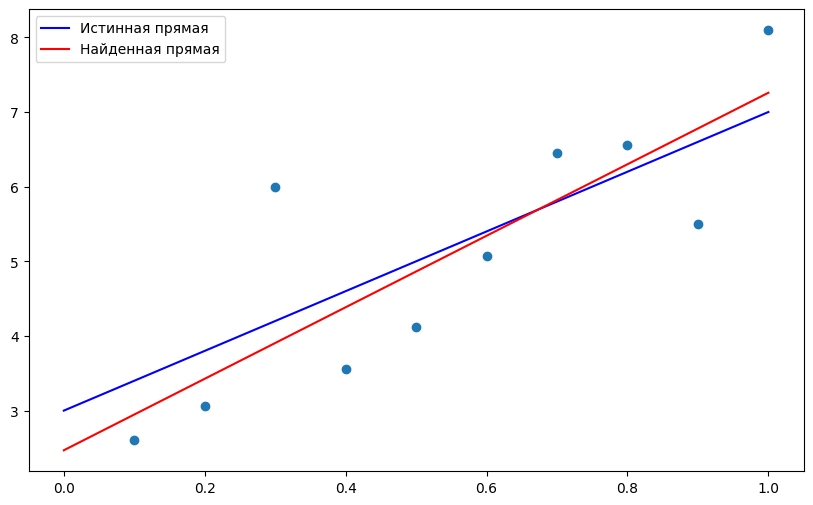

Настоящие парметры 4, 3, σ = 0.4444444444444444 полученные их оценки 3.212353778319302, 3.4871953174129, дисперсия отклонений 0.18667424936916102


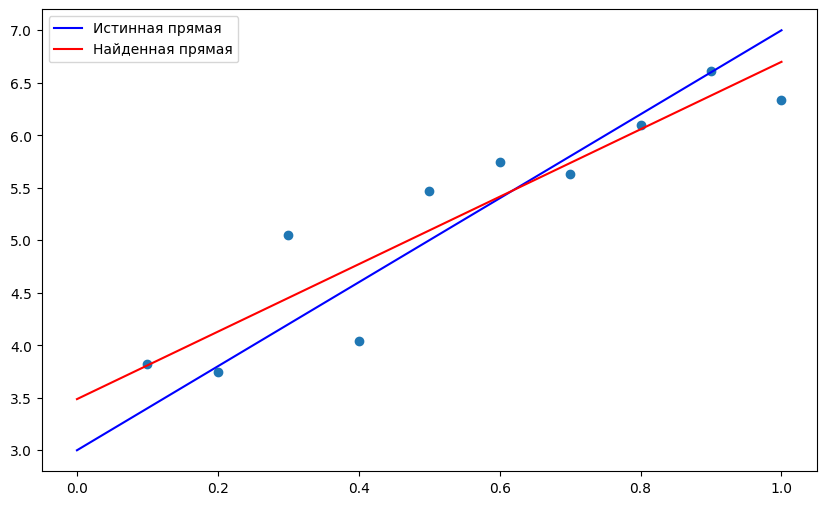

Настоящие парметры 4, 3, σ = 1 полученные их оценки 4.536734460074043, 2.9742713817131428, дисперсия отклонений 0.6352450244277391


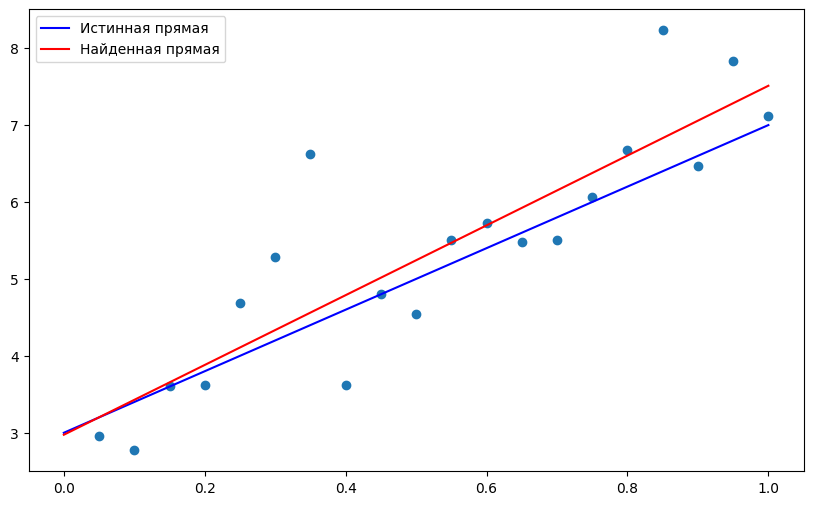

Настоящие парметры 4, 3, σ = 0.4444444444444444 полученные их оценки 4.280361374262846, 2.788956693103366, дисперсия отклонений 0.24110323118298357


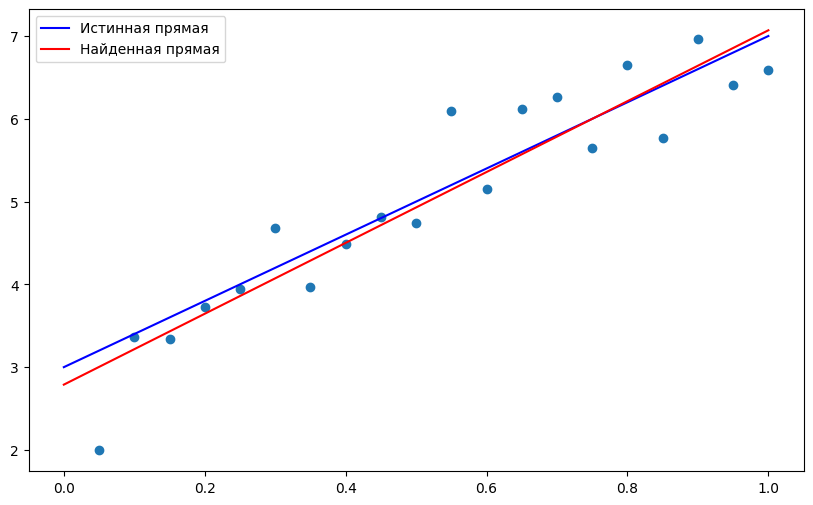

Настоящие парметры 4, 3, σ = 1 полученные их оценки 3.364370210115276, 3.322222418024869, дисперсия отклонений 0.8089586830249011


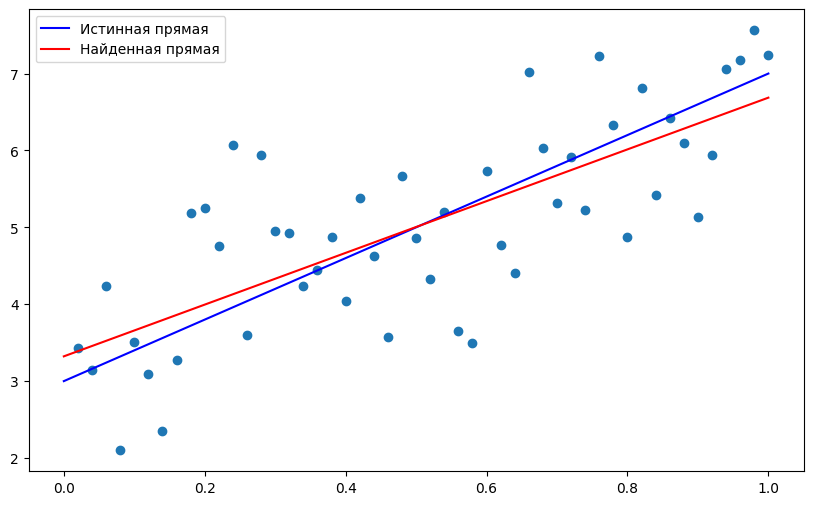

Настоящие парметры 4, 3, σ = 0.4444444444444444 полученные их оценки 4.023599042050135, 3.0203692284675423, дисперсия отклонений 0.18868430684952717


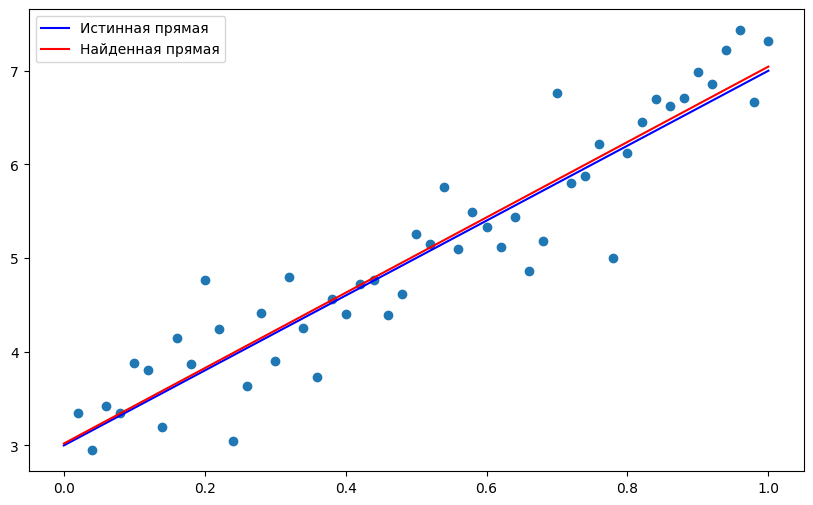

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def method_of_least_squares(m_values, a, b, σ_values):
    X_line = np.linspace(0, 1, 100)
    for m in m_values:
        X = np.arange(1, m+1) / m
        for σ in σ_values:
            ε_sample = np.random.normal(0, σ, m)     #Мы знаем, что Х верный, ошибка в У, смещение иы смортим по нему 
            Y = a * X + b + ε_sample
            X_mean = np.mean(X)
            Y_mean = np.mean(Y)
            a_est = np.sum((X - X_mean)*(Y - Y_mean)) / np.sum((X - X_mean)**2)
            b_est = Y_mean - a_est * X_mean
            residuals = Y - (a_est * X + b_est) #вертикальные расстояния до идеальной прямой
            var_est = np.sum(residuals**2) / (m - 2) #насколько мы вообще угадали с этой идефльной прямой - какой разброс
            print(f"Настоящие парметры {a}, {b}, σ = {σ} полученные их оценки {a_est}, {b_est}, дисперсия отклонений {var_est}")
            plt.figure(figsize=(10,6))
            plt.scatter(X, Y)
            plt.plot(X_line, a * X_line + b, color = 'blue', label = 'Истинная прямая')
            plt.plot(X_line, a_est * X_line + b_est, color = 'red', label = 'Найденная прямая')
            plt.legend()
            plt.show()
            
m_values = [10, 20, 50]
a = 4
b = 3
σ_values = [1, a/9]
method_of_least_squares(m_values, a, b, σ_values)

2. Теперь посмотрим, как наши методы реагируют на сильно отклоняющиеся от прямой значения Y .
Для этого в массиве Y нужно изменить несколько элементов.

(a) Пусть Yt = aXt + b + 5σ для некоторого (одного!) t. Построить новую прямую методом МНК,
сравнить с прямой МНК, построенной в задаче 1. Рассмотреть случаи, когда Xt находится в
центре массива и когда Xt расположен на краю.

(b) Если Yt = aXt +b+5σ, а Ys = aXs +b−5σ, будут ли эти выбросы компенсировать друг друга?
Рассмотреть случаи, когда Xt, Xs находятся а) рядом б) на разных концах ряда.

Настоящие парметры 4, 3, σ = 1 полученные их оценки 1.8664473032416653, 4.209733699075341, дисперсия отклонений 1.6233810785618217, размер выборки m = 10


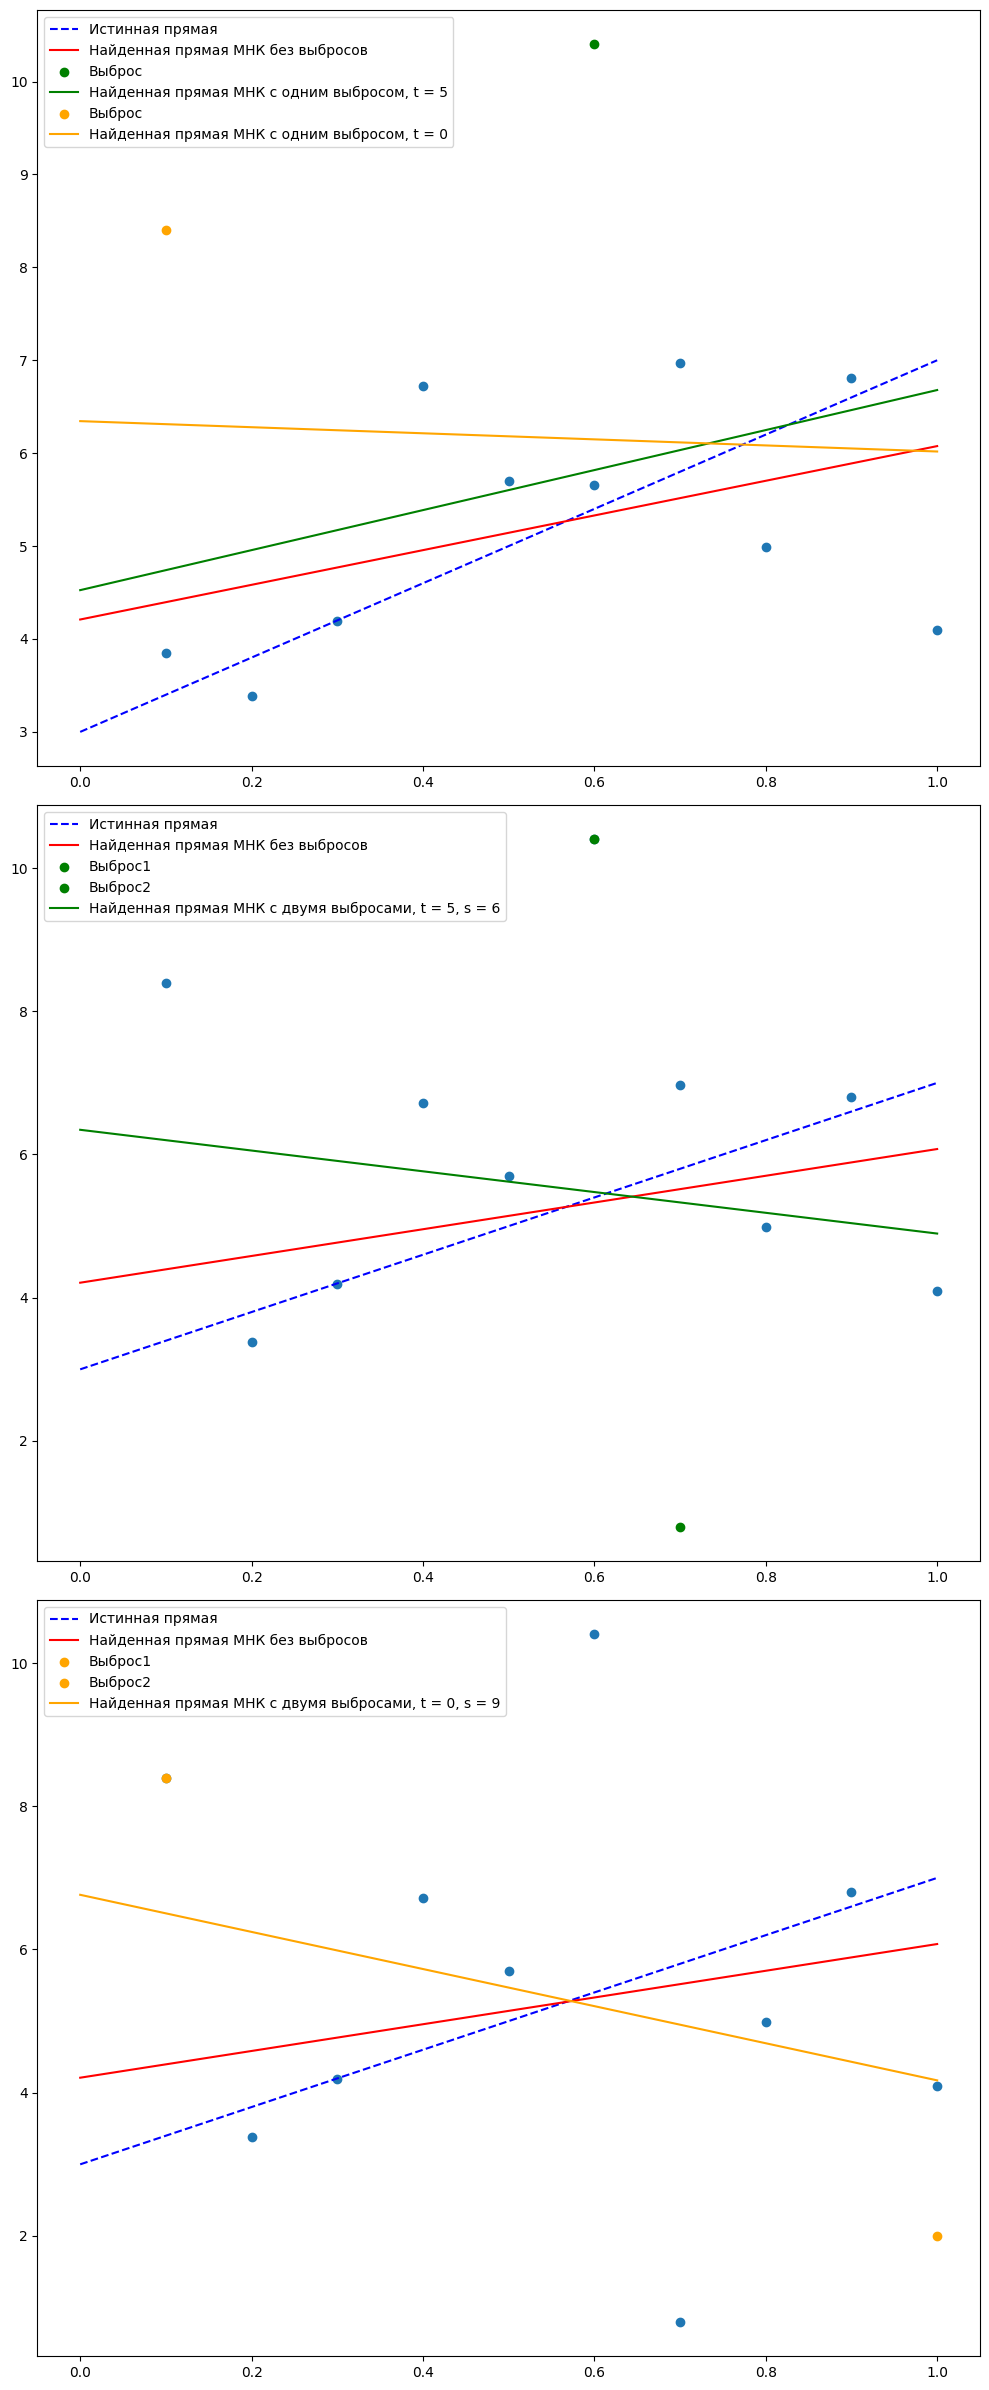

Настоящие парметры 4, 3, σ = 0.4444444444444444 полученные их оценки 4.889056910322948, 2.491595566644171, дисперсия отклонений 0.14450380113741768, размер выборки m = 10


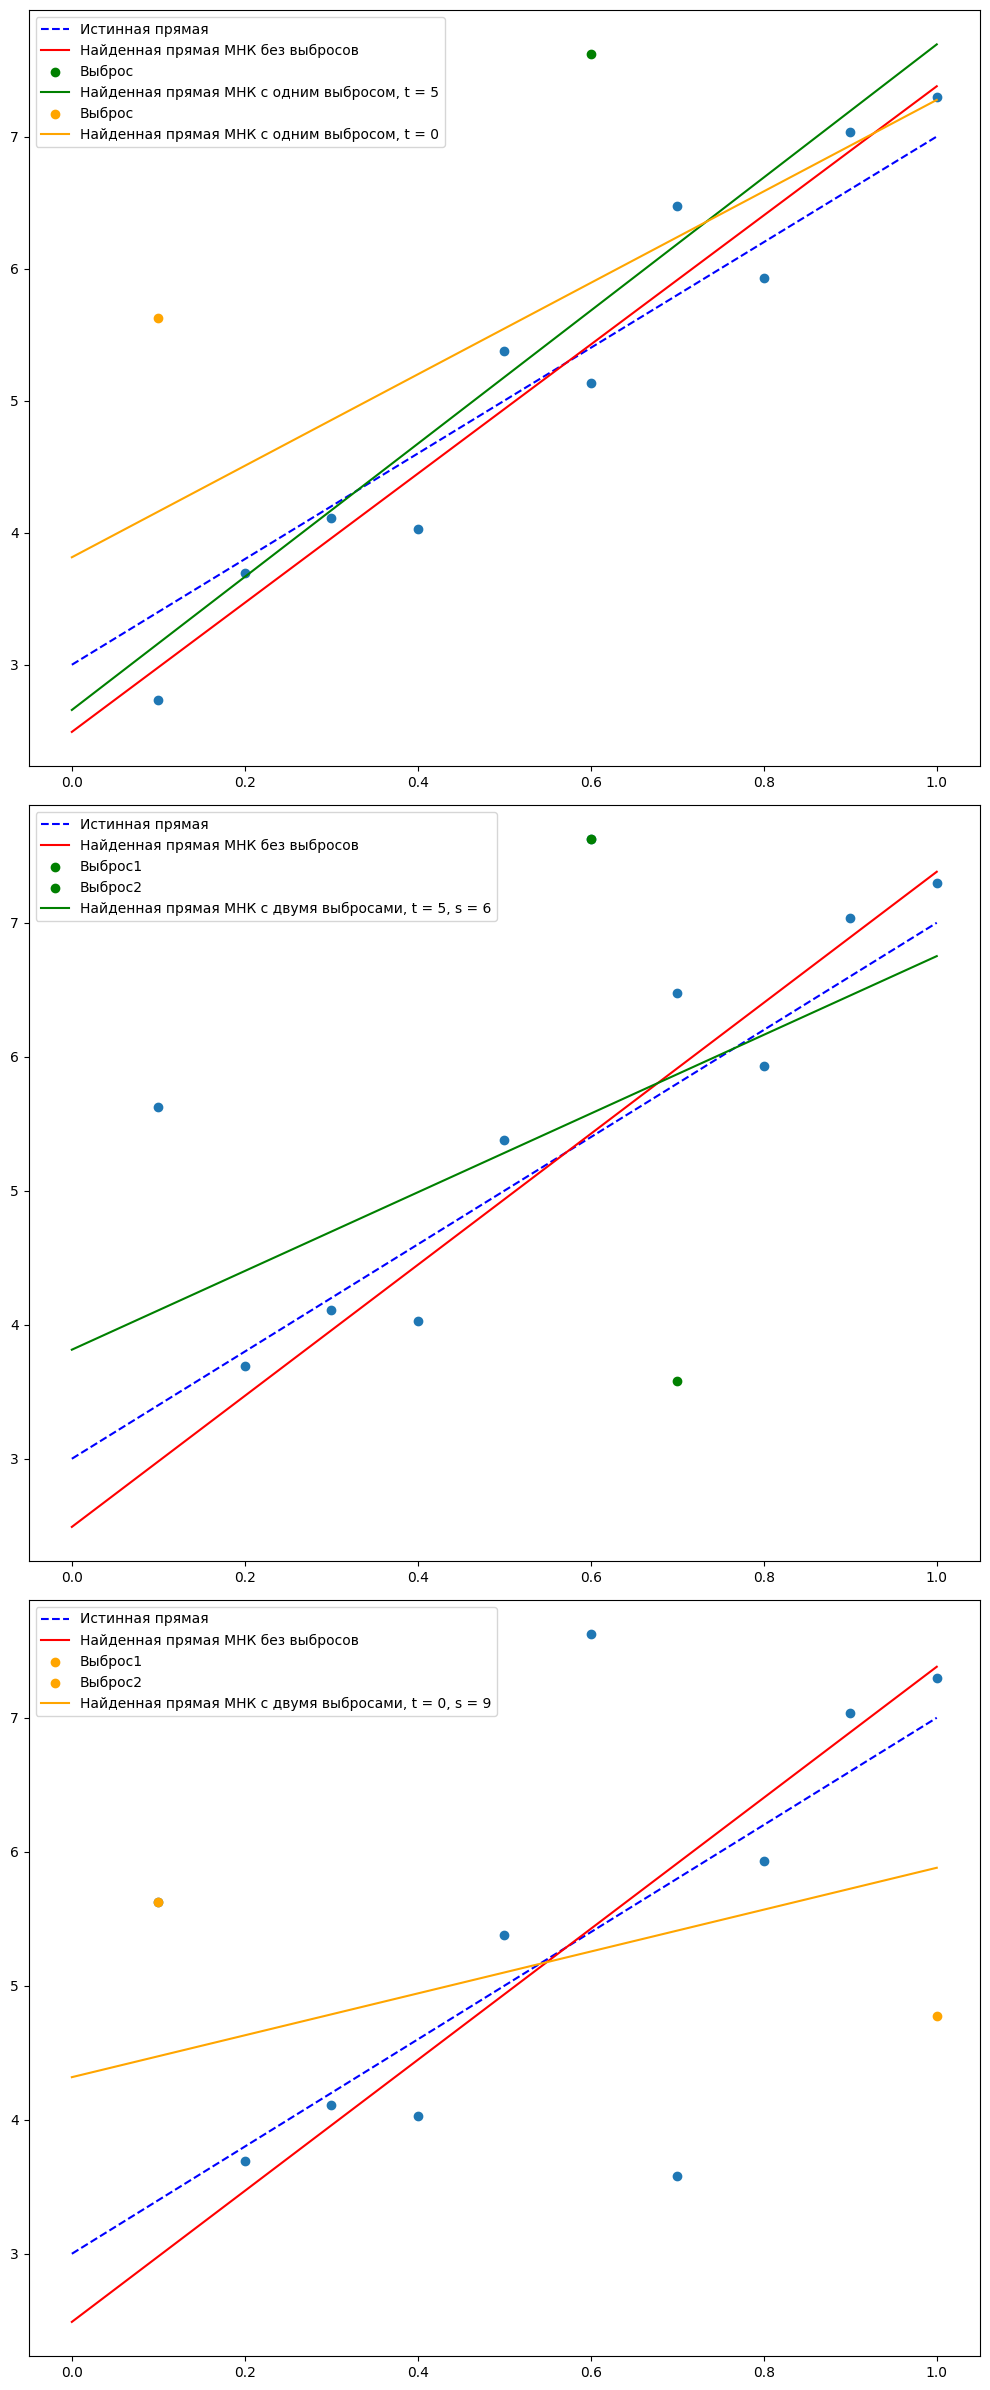

Настоящие парметры 4, 3, σ = 1 полученные их оценки 4.04600832690579, 2.7498026688640476, дисперсия отклонений 0.910002268321175, размер выборки m = 20


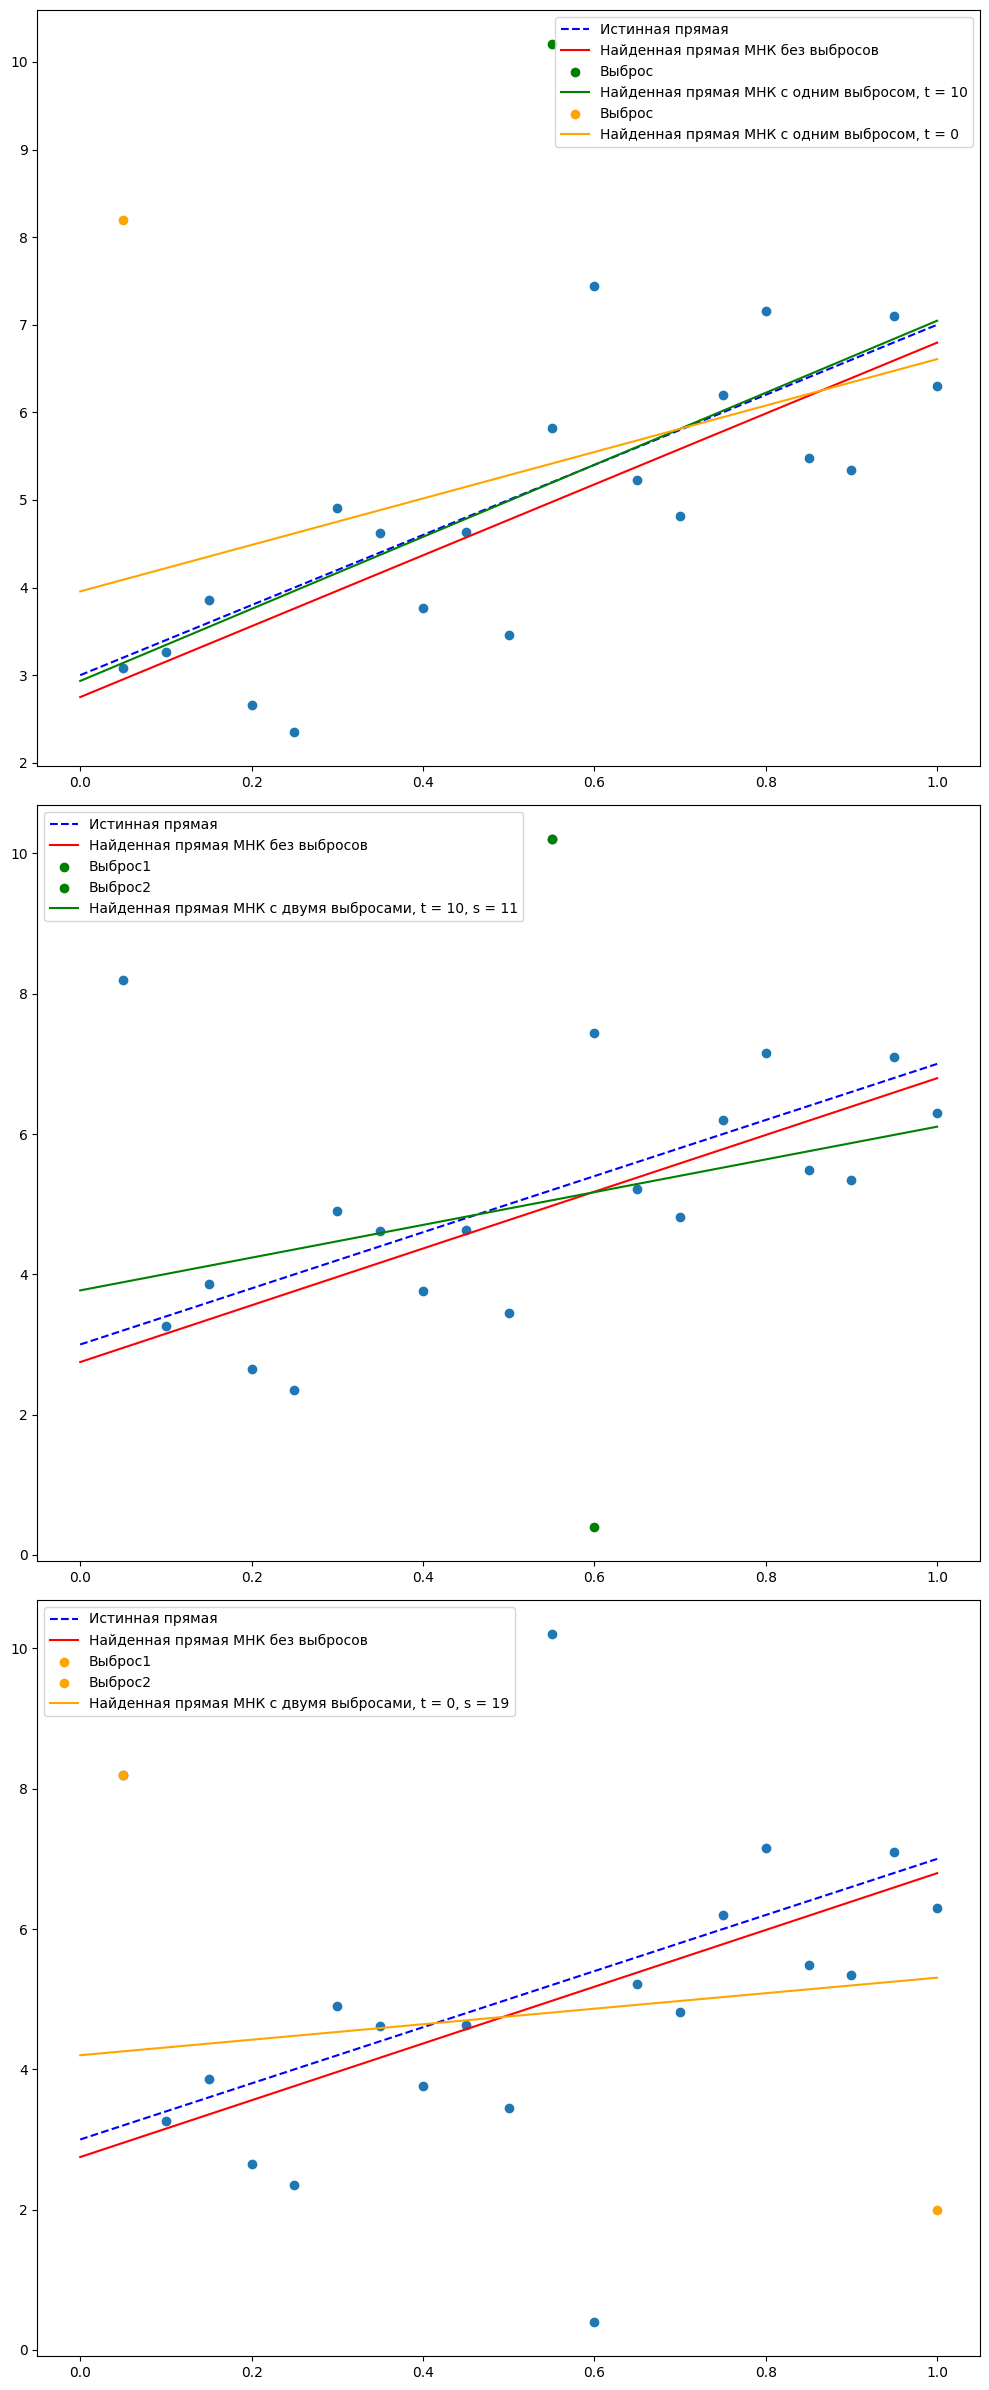

Настоящие парметры 4, 3, σ = 0.4444444444444444 полученные их оценки 3.3408015998522256, 3.469128492702504, дисперсия отклонений 0.29376517997898266, размер выборки m = 20


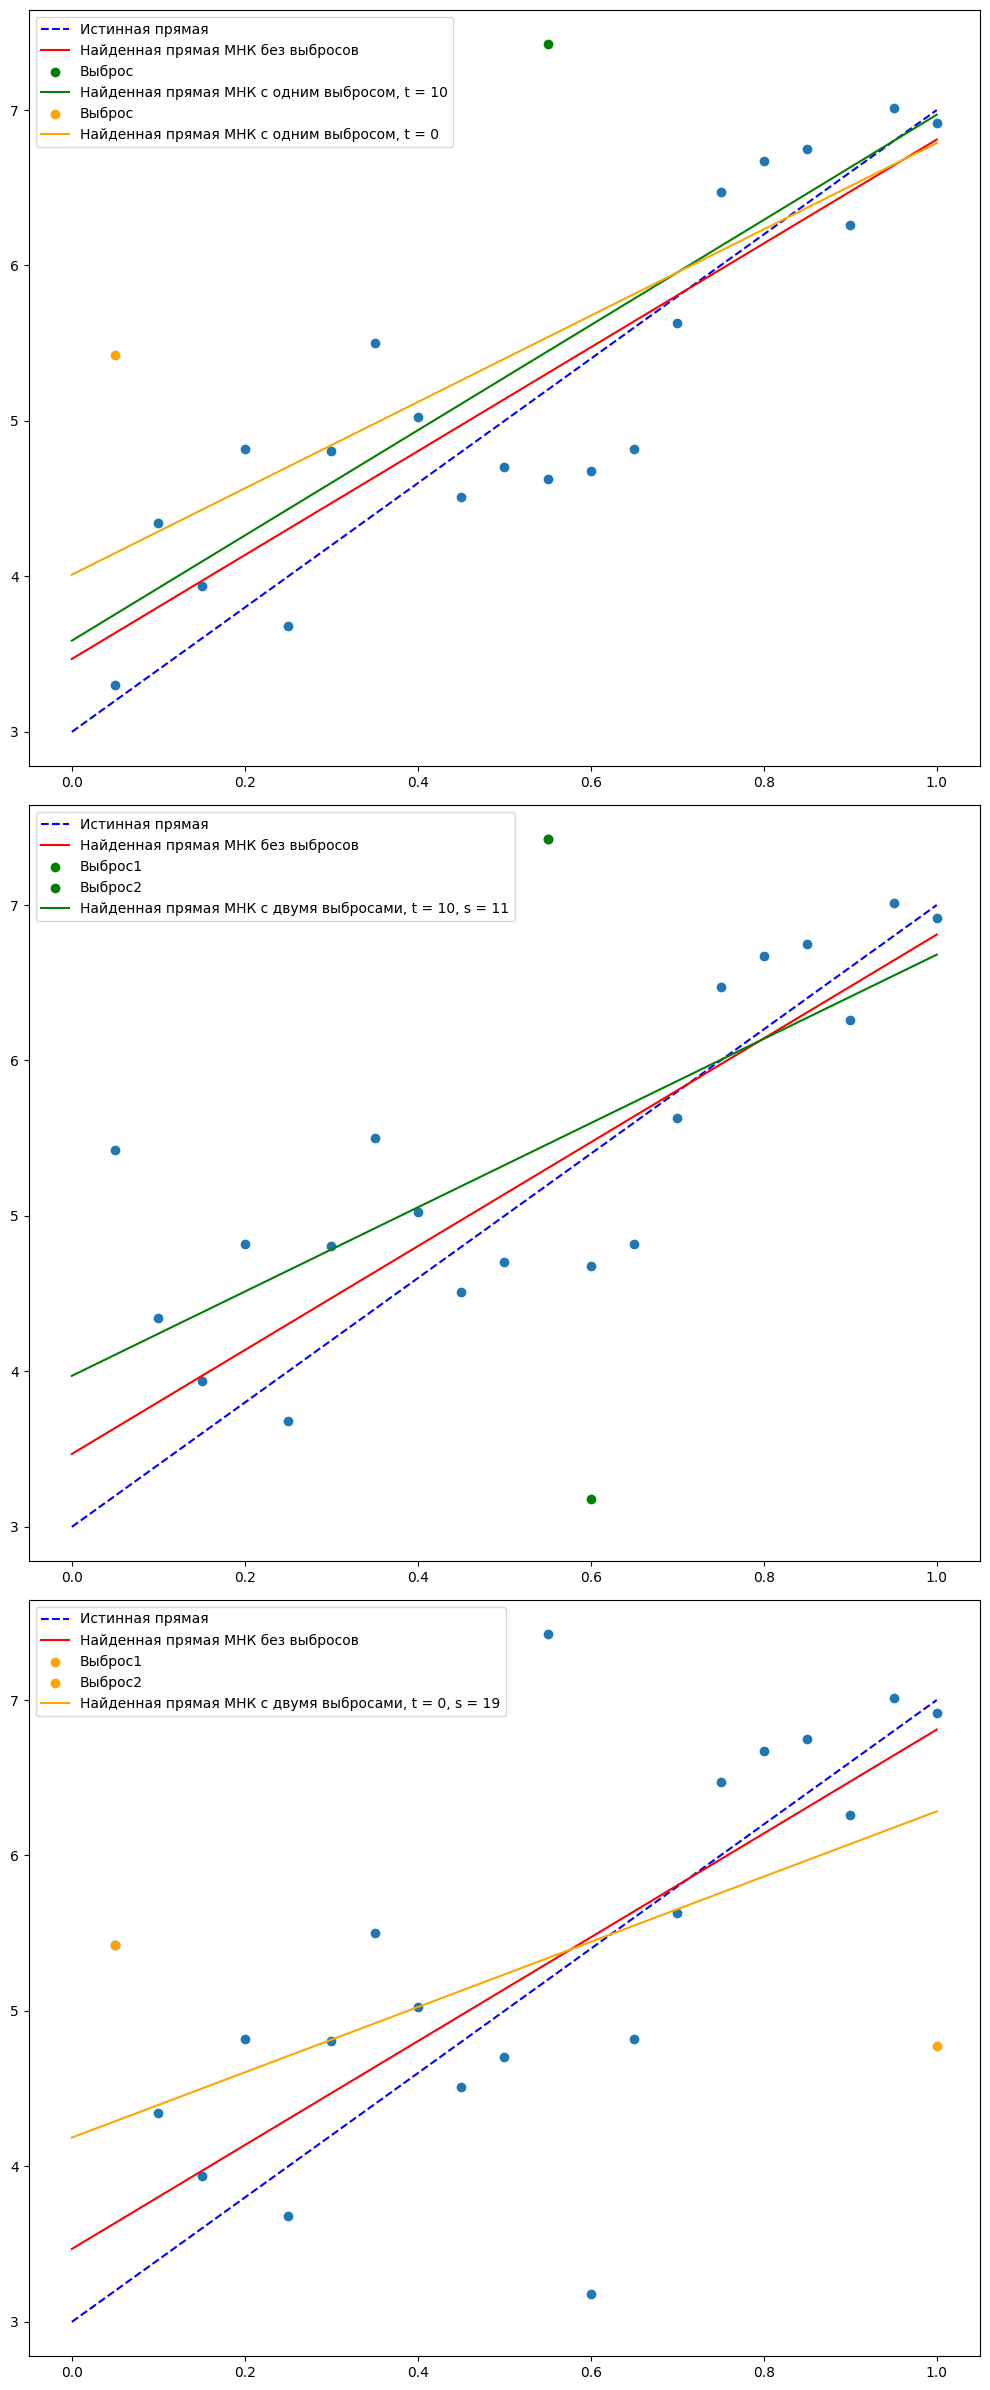

Настоящие парметры 4, 3, σ = 1 полученные их оценки 3.9879248158115628, 3.1603017283259645, дисперсия отклонений 1.2674848990955, размер выборки m = 50


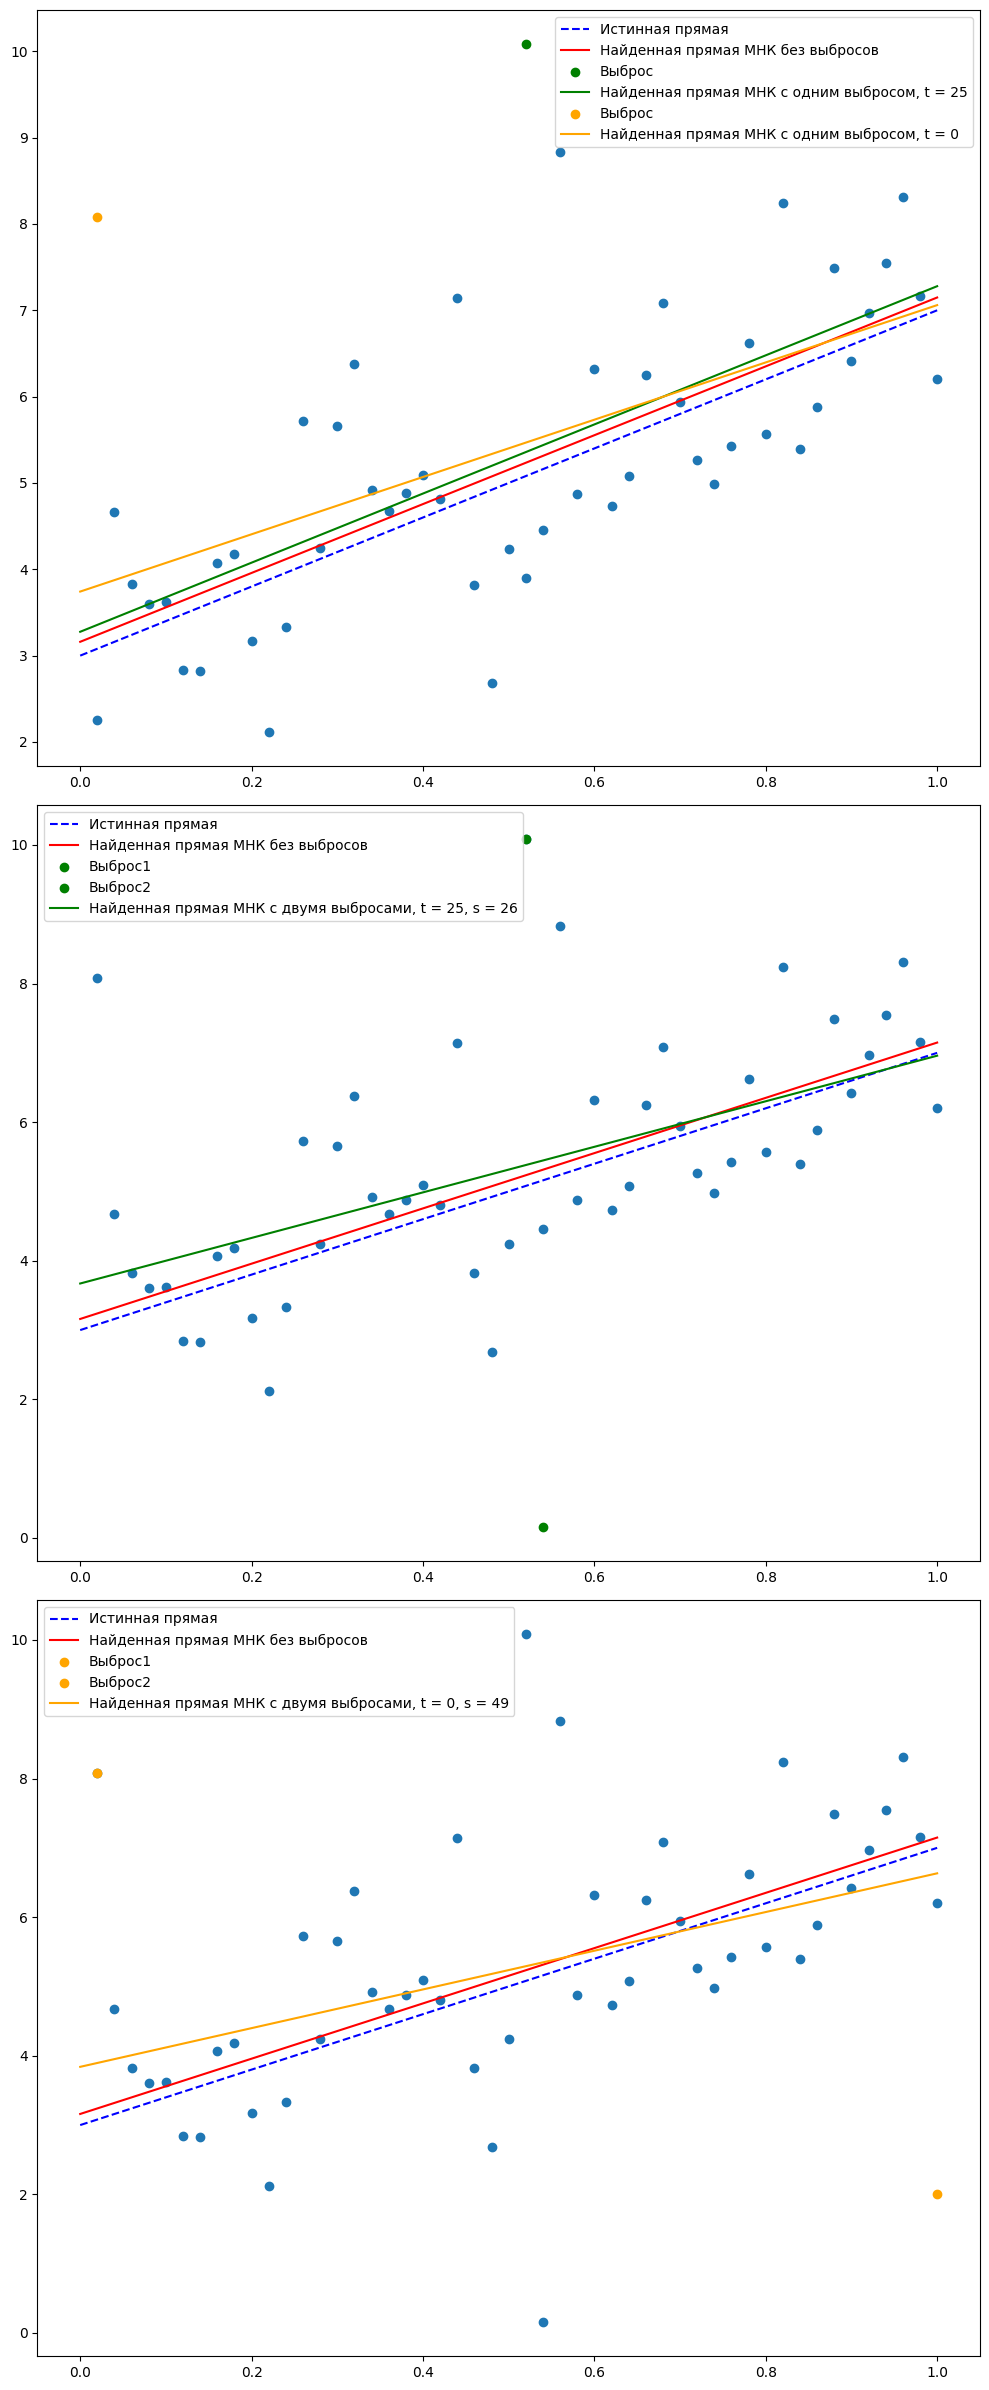

Настоящие парметры 4, 3, σ = 0.4444444444444444 полученные их оценки 3.8449334031821016, 3.0826295628827936, дисперсия отклонений 0.2400742026332209, размер выборки m = 50


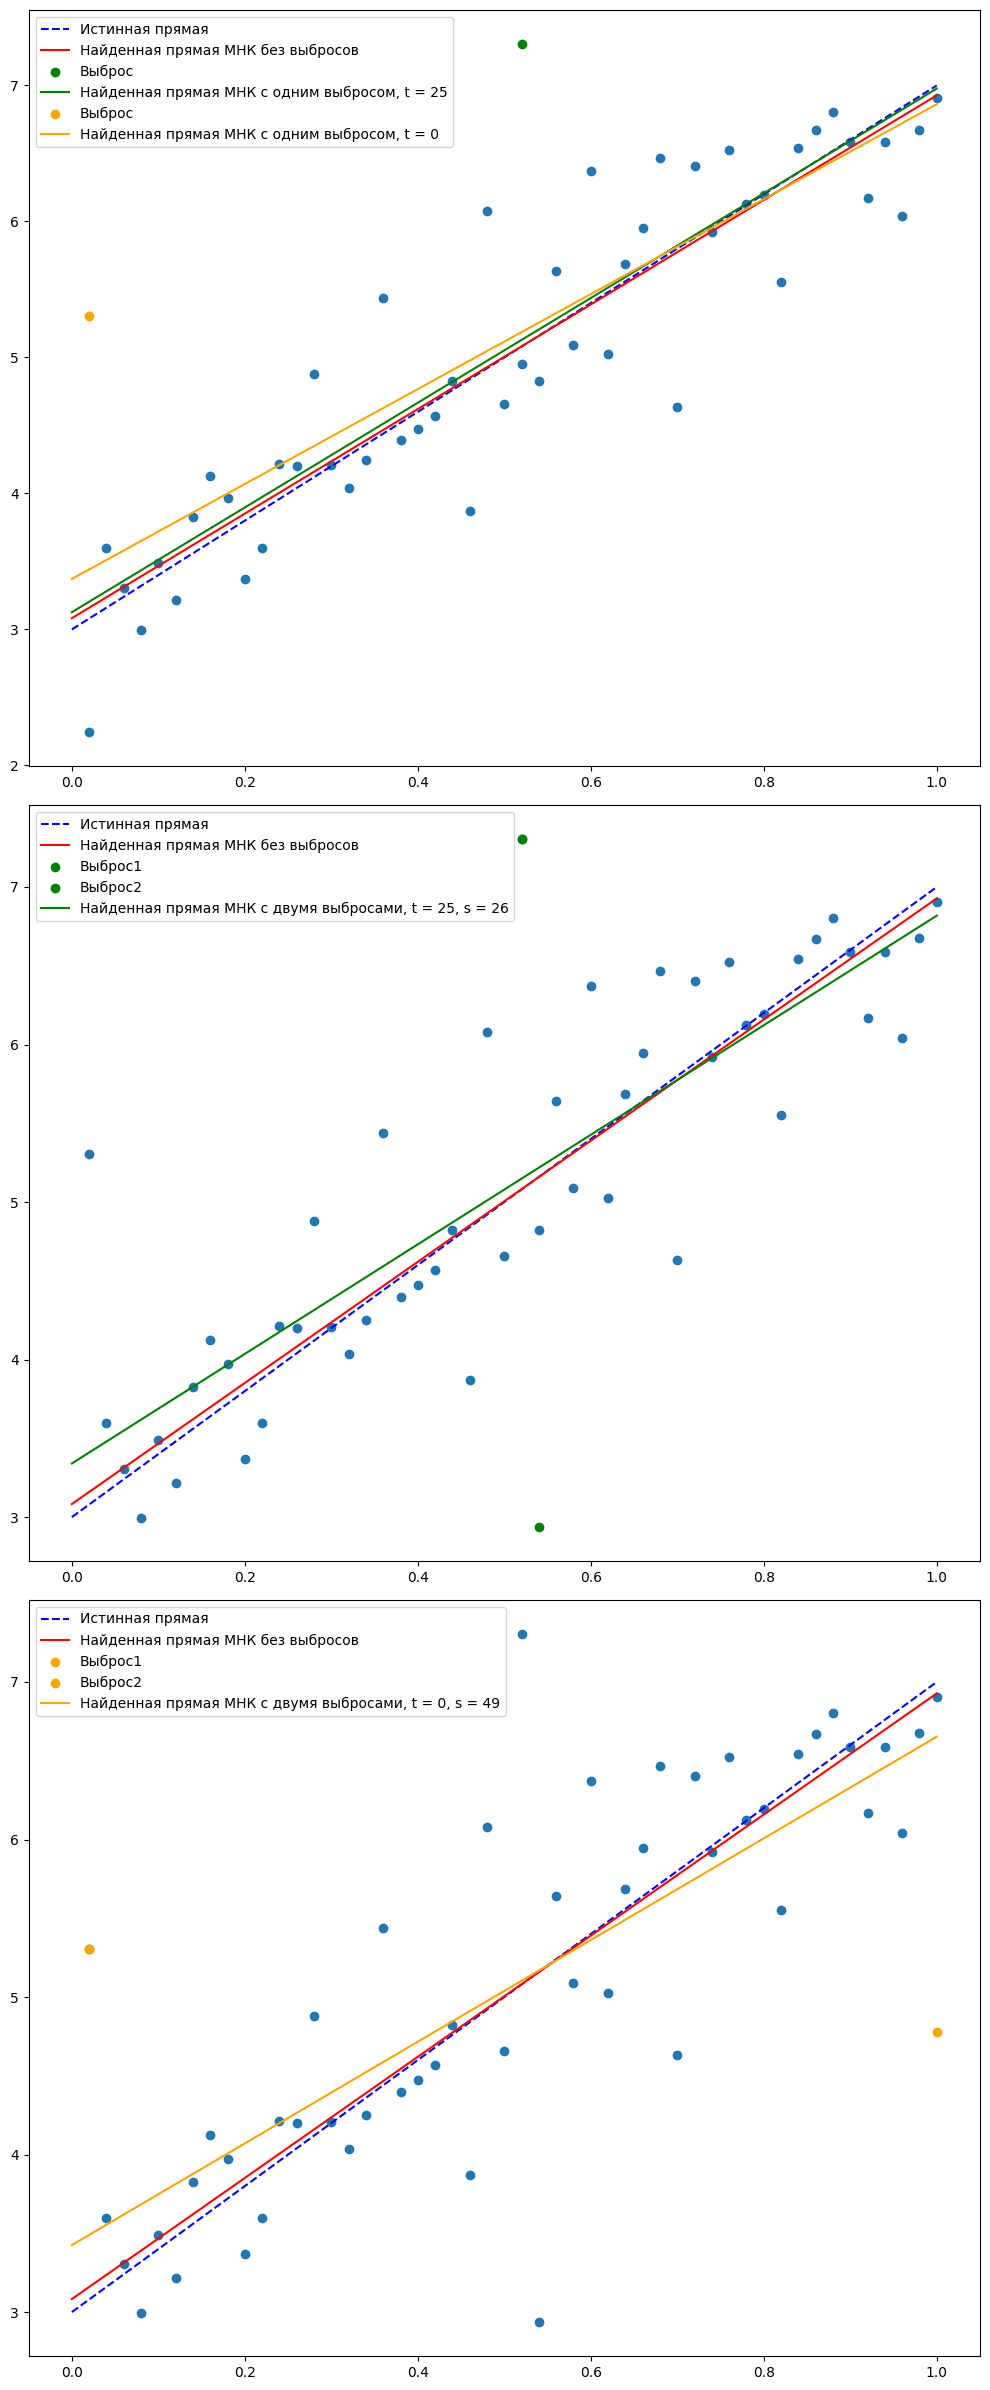

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def method_of_least_squares(m_values, a, b, σ_values):
    X_line = np.linspace(0, 1, 100)
    for m in m_values:
        X = np.arange(1, m+1) / m
        t_values = [m // 2, 0]
        for σ in σ_values:
            ε_sample = np.random.normal(0, σ, m)     #Мы знаем, что Х верный, ошибка в У, смещение иы смортим по нему 
            Y = a * X + b + ε_sample
            X_mean = np.mean(X)
            Y_mean = np.mean(Y)
            a_est = np.sum((X - X_mean)*(Y - Y_mean)) / np.sum((X - X_mean)**2)
            b_est = Y_mean - a_est * X_mean
            residuals = Y - (a_est * X + b_est) #вертикальные расстояния до идеальной прямой
            var_est = np.sum(residuals**2) / (m - 2) #насколько мы вообще угадали с этой идефльной прямой - какой разброс
            print(f"Настоящие парметры {a}, {b}, σ = {σ} полученные их оценки {a_est}, {b_est}, дисперсия отклонений {var_est}, размер выборки m = {m}")
            plt.figure(figsize=(10,24))
            plt.subplot(3, 1, 1)
            plt.scatter(X, Y)
            plt.plot(X_line, a * X_line + b, '--', color = 'blue', label = 'Истинная прямая')
            plt.plot(X_line, a_est * X_line + b_est, color = 'red', label = 'Найденная прямая МНК без выбросов')
            OLS_with_one_outlier(X_line, X_mean, σ, t_values, X, Y)
            OLS_with_two_outlier(X_line, X_mean, σ, t_values, X, Y, m, a_est, b_est)
            plt.tight_layout()
            plt.show()
            
def OLS_with_one_outlier(X_line, X_mean, σ, t_values, X, Y):
    colors = ['green', 'orange']
    for i, t in enumerate(t_values):
        Y[t] =  a * X[t] + b + 5 * σ
        Y_mean = np.mean(Y)
        a_one_out = np.sum((X - X_mean)*(Y - Y_mean)) / np.sum((X - X_mean)**2)
        b_one_out = Y_mean - a_one_out * X_mean
        plt.scatter(X[t], Y[t], color = colors[i], label='Выброс')
        plt.plot(X_line, a_one_out * X_line + b_one_out, color = colors[i], label = f'Найденная прямая МНК с одним выбросом, t = {t}')
        plt.legend()
        
def OLS_with_two_outlier(X_line, X_mean, σ, t_values, X, Y, m, a_est, b_est):
    colors = ['green', 'orange']
    for i, t in enumerate(t_values):
        plt.subplot(3, 1, i+2)
        plt.scatter(X, Y)
        plt.plot(X_line, a * X_line + b, '--', color = 'blue', label = 'Истинная прямая')
        plt.plot(X_line, a_est * X_line + b_est, color = 'red', label = 'Найденная прямая МНК без выбросов')
        Y[t] =  a * X[t] + b + 5 * σ
        plt.scatter(X[t], Y[t], color = colors[i], label='Выброс1')
        if i == 0:
            Y[t + 1] = a * X[t + 1] + b - 5 * σ
            plt.scatter(X[t+1], Y[t+1], color = colors[i], label='Выброс2')
            Y_mean = np.mean(Y)
            a_two_out = np.sum((X - X_mean)*(Y - Y_mean)) / np.sum((X - X_mean)**2)
            b_two_out = Y_mean - a_two_out * X_mean
            plt.plot(X_line, a_two_out * X_line + b_two_out, color = colors[i], label = f'Найденная прямая МНК с двумя выбросами, t = {t}, s = {t+1}')
            plt.legend()
        else:
            Y[m - 1] = a * X[m - 1] + b - 5 * σ
            plt.scatter(X[m-1], Y[m-1], color = colors[i], label='Выброс2')
            Y_mean = np.mean(Y)
            a_two_out = np.sum((X - X_mean)*(Y - Y_mean)) / np.sum((X - X_mean)**2)
            b_two_out = Y_mean - a_two_out * X_mean
            plt.plot(X_line, a_two_out * X_line + b_two_out, color = colors[i], label = f'Найденная прямая МНК с двумя выбросами, t = {t}, s = {m-1}')
            plt.legend()
   

m_values = [10, 20, 50]
a = 4
b = 3
σ_values = [1, a/9]
method_of_least_squares(m_values, a, b, σ_values)

3. Познакомимся с общей линейной моделью. Посмотрим, как метод МНК работает для подгонки
многочлена. Пусть X – тот же массив, Yi = a0 + a1Xi + · · · + akXk + εi, εi ∼ N (0, σ2) независимы(σ = 1).

(a) Построить МНК-оценки коэффициентов, считая что Y = a0 + a1X + · · · + adXd + ε, где
d = k, k + 1, k + 3, сравнить их с исходными.

(b) Построить на одном графике облако точек, полученный многочлен, исходный многочлен (отдельно для разных d).

(c) Построить прогноз в точках x = 1.2, 1.5, 2 для разных d, сравнить эти прогнозы.

(d) Сравнить графики многочленов, полученных в задаче при разных d, за пределами отрезка [0, 1].

Мой многочлен такой y = x^4 − 3x^2 + x + 1

Истинные коэффициенты: [1, 1, -3, 0, 1]
при х=1.2, значение истинного многочлена = -0.04640000000000022
при х=1.5, значение истинного многочлена = 0.8125
при х=2.0, значение истинного многочлена = 7.0
Оценённые коэффициенты для d=4: [ 1.10559873 -0.62442768  3.64899434 -9.95496896  5.73946232]
  Прогноз при x=1.2: 0.3100000695941354
  Прогноз при x=1.5: 3.8372022260405423
  Прогноз при x=2.0: 26.644366142121413
Оценённые коэффициенты для d=5: [  1.05357422   0.93008776  -7.21630404  18.99381495 -26.80757158
  13.01230741]
  Прогноз при x=1.2: 1.390118284830006
  Прогноз при x=1.5: 13.41502545945957
  Прогноз при x=2.0: 113.4717448546046
Оценённые коэффициенты для d=7: [ 1.18251288e+00 -6.82355489e+00  1.03347842e+02 -6.21761681e+02
  1.79518453e+03 -2.68265690e+03  1.99087041e+03 -5.79585202e+02]
  Прогноз при x=1.2: -17.45462761216504
  Прогноз при x=1.5: -383.76836980167354
  Прогноз при x=2.0: -8466.435096685644


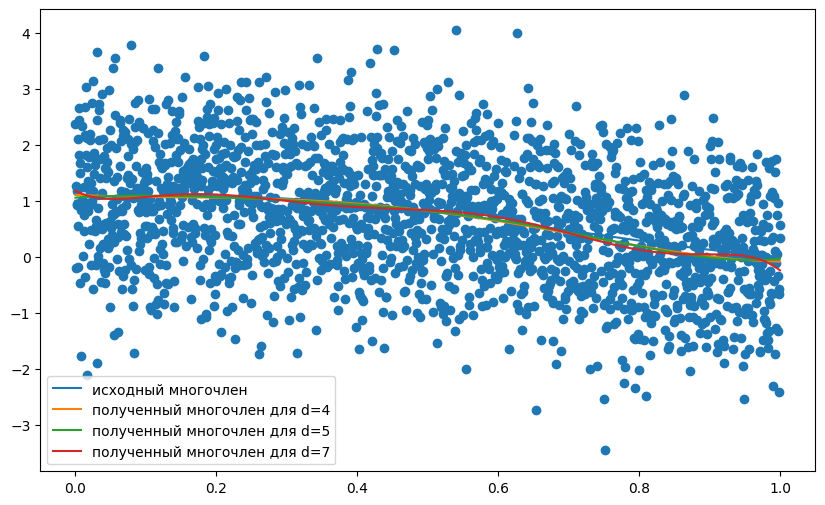

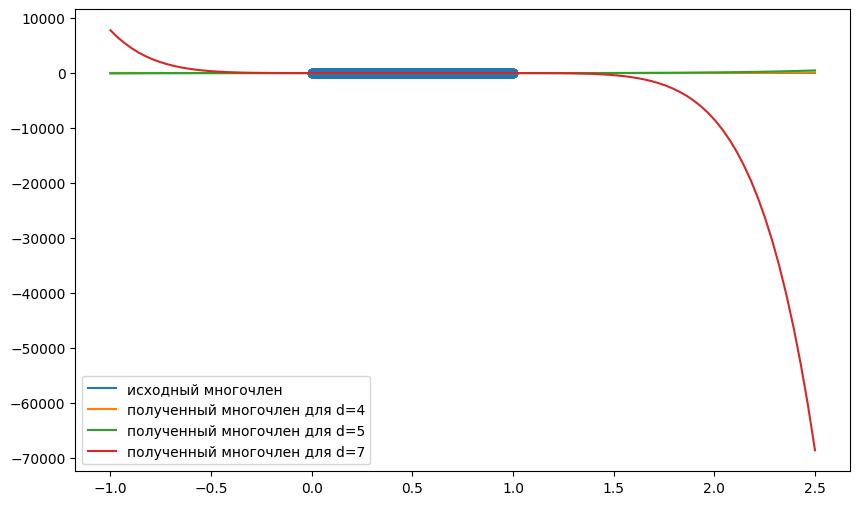

In [1]:
import numpy as np
import matplotlib.pyplot as plt

a_values = [1, 1, -3, 0, 1] #коэффициенты a0, a1, a2, a3, a4
k = 4
d_values = [k, k+1, k+3]
def Y_true_func(x):
    return a_values[0] + a_values[1]*x + a_values[2]*x**2 + a_values[3]*x**3 + a_values[4]*x**4
def fit_polynomial(d_values):
    m = 2000 #размер выборки
    X = np.arange(1, m+1) / m
    Y_true = Y_true_func(X)
    #или такая темка Phi = np.array([X**deg for deg in range(len(a_values))]).T
    #Y_true = Phi @ a_values  # матричное умножение
    Y = Y_true + np.random.normal(0, 1, m)
    predictions = {}
    plt.figure(figsize=(10,6))
    plt.scatter(X, Y)
    plt.plot(X, Y_true, label='исходный многочлен')
    plt.legend()
    print("Истинные коэффициенты:", a_values)
    X_pred = np.array([1.2, 1.5, 2.0])
    for x in X_pred:
        print(f"при х={x}, значение истинного многочлена = {a_values[0] + a_values[1]*x + a_values[2]*x**2 + a_values[3]*x**3 + a_values[4]*x**4}")
    coeffs_est = []
    for d in d_values:
        degrees = range(d+1)
        columns = [X**deg for deg in degrees]
        Phi = np.array(columns).T
        coeffs = np.linalg.lstsq(Phi, Y, rcond=None)[0]
        coeffs_est.append(coeffs)
        Y_fit = Phi @ coeffs
        print(f"Оценённые коэффициенты для d={d}: {coeffs}")
        plt.plot(X, Y_fit, label = f"полученный многочлен для d={d}")
        plt.legend()
        
        Phi_pred = np.array([X_pred**deg for deg in degrees]).T #пункт с
        Y_pred = Phi_pred @ coeffs
        predictions[d] = Y_pred
        for i, x in enumerate(X_pred):
            print(f"  Прогноз при x={x}: {Y_pred[i]}") 
    return coeffs_est, X, Y

def func_с(d_values, coeffs_est, X_train, Y_train, m):  
    X_c = np.linspace(-1, 2.5, m) #вне [0,1] 
    Y_true_c = Y_true_func(X_c)   #пункт d
    plt.figure(figsize=(10, 6))
    plt.scatter(X_train, Y_train) 
    plt.plot(X_c, Y_true_c, label='исходный многочлен')
    for idx, d in enumerate(d_values):
        Phi_c = np.array([X_c**deg for deg in range(d+1)]).T  
        coeffs = coeffs_est[idx] 
        y_c = Phi_c @ coeffs
        plt.plot(X_c, y_c, label = f"полученный многочлен для d={d}")
    plt.legend()
    plt.show()

coeffs_est, X_train, Y_train = fit_polynomial(d_values)

func_с(d_values, coeffs_est, X_train, Y_train, 100)
